# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")

# IMPORT DF

In [3]:
file_path = "../1.DATASET/CMI_NN_V2.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.0,50.8,932.498,NaN,5.0,...,1.0,19.5413,32.6909,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.5
1,1,9,0,NaN,14.035590,48.0,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.0
2,2,10,1,71.0,16.648696,56.5,75.6,1115.380,94.0,5.0,...,1.0,25.5129,42.3800,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.0


In [4]:
df.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [5]:
cols=[ 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL']

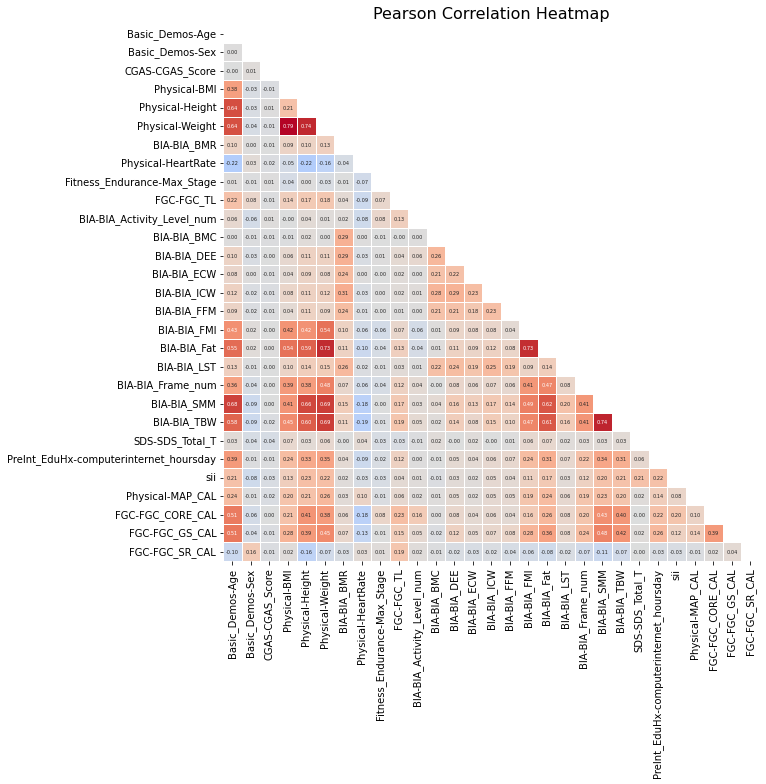

In [6]:
# column selection
df_corr = df[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# create var FFM

In [7]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")

In [8]:
df.loc[((df['BIA-BIA_FFM'].isnull()) | (df['BIA-BIA_FFM']<=0) | (df['BIA-BIA_FFM']>=df['Physical-Weight'])), 'BIA-BIA_FFM'] = (df['Physical-Weight'] - df['BIA-BIA_Fat'])

some negative values appeared

In [9]:
analyze_feature(df, 'BIA-BIA_FFM')

Analyzed column: BIA-BIA_FFM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: True
Number of negative values: 20
Minimum value: -22.99956666666666
Maximum value: 204.63764
Range (max - min): 227.63720666666666

Quantiles:
  Q10 (0.1): 34.66025347269399
  Q25 (0.25): 44.39373258803069
  Q50 (0.5): 55.6
  Q75 (0.75): 70.43935
  Q90 (0.9): 91.9085126773956
  Q99 (0.99): 132.7333463837201


there are mistakes in data!

In [10]:
df[["Physical-Weight", "BIA-BIA_Fat"]][df["Physical-Weight"] < df["BIA-BIA_Fat"]]

,Physical-Weight,BIA-BIA_Fat
3473,37.0,59.999567
4009,3.0,15.626267
4182,4.0,8.446926
4264,51.0,59.999567
4270,47.8,59.999567
4380,18.5,23.049220
4393,58.7,59.999567
4709,52.1,59.999567
4759,3.9,8.446926
4837,2.3,15.626267


In [ ]:
df[["Physical-Weight", "BIA-BIA_FFM"]][df["Physical-Weight"] < df["BIA-BIA_FFM"]]

,Physical-Weight,BIA-BIA_FFM


In [13]:
df[["Physical-Weight", "BIA-BIA_TBW"]][df["Physical-Weight"] < df["BIA-BIA_TBW"]]

,Physical-Weight,BIA-BIA_TBW
71,38.400000,42.38
102,41.635709,42.38
166,40.622225,42.50
217,39.344796,42.38
246,42.374804,42.38
...,...,...
7917,40.500000,42.50
8162,39.900000,42.50
8175,43.000000,48.00
8198,42.100000,42.50


In [ ]:
df[["BIA-BIA_SMM", "BIA-BIA_FFM"]][df["BIA-BIA_FFM"] < df["BIA-BIA_SMM"]]

,BIA-BIA_SMM,BIA-BIA_FFM
78,39.032050,33.400396
194,25.630000,24.252887
280,62.700900,61.066200
366,37.698900,34.564691
618,33.319250,32.008204
...,...,...
8291,65.962889,56.621896
8365,41.831134,22.168945
8425,56.414500,27.500433
8445,45.178173,40.810600


In [15]:
df[["BIA-BIA_SMM", "Physical-Weight"]][df["Physical-Weight"] < df["BIA-BIA_SMM"]]

,BIA-BIA_SMM,Physical-Weight
1045,50.94020,44.192196
1287,83.83745,49.600000
1464,62.70090,44.192196
2738,83.83745,49.200000
2770,83.83745,75.600000
3147,83.83745,52.800000
3162,62.70090,47.302107
3205,83.83745,70.400000
3729,83.83745,77.000000
3842,62.70090,44.192196


compare the distributions with "BIA-BIA_FFM" before. now it looks more the distribution of weight, bmi ecc

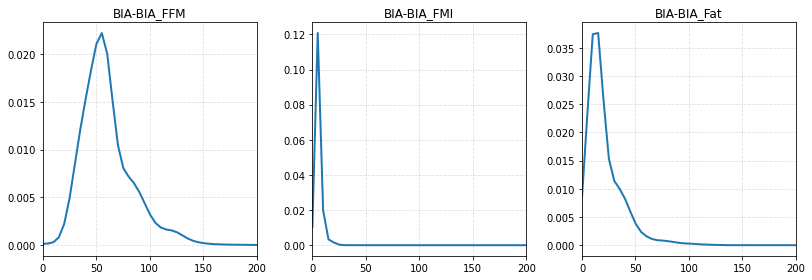

In [11]:
from scipy.stats import gaussian_kde, iqr

cols = [
    "BIA-BIA_FFM",
    "BIA-BIA_FMI",
    "BIA-BIA_Fat"
]

n = len(cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, ax = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
ax = ax.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna().values
    kde = gaussian_kde(data, bw_method=0.3)

    x_vals = np.linspace(0, 1000, 200)

    ax[i].plot(x_vals, kde(x_vals), linewidth=2)
    ax[i].set_title(col)
    ax[i].set_xlim(0, 200)
    ax[i].grid(True, linestyle='--', alpha=0.4)

for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()